# Optical Depth and Contribution Analysis

The spectrum is the most visible product of a forward model, but TauREx can also expose the intermediate pieces used to build it. Those internal arrays are valuable when you want to answer questions like: which contribution dominates, and at which wavelengths is the atmosphere becoming optically thick?

This notebook is best read as a diagnostic notebook. Instead of starting with the final plot and stopping there, we look underneath the spectrum to see how TauREx assembled it using the active clear-sky contributions in the model.

In [2]:
from _shared import build_transmission_model

context = build_transmission_model(include_cia=False, include_rayleigh=True, download=False)
tm = context['tm']
wngrid, rprs, tau, _ = tm.model()
wlgrid = 10000 / wngrid[::-1]
tau = tau[..., ::-1]

print(f'Spectrum shape: {rprs.shape}')
print(f'Optical-depth shape: {tau.shape}')

Spectrum shape: (76744,)
Optical-depth shape: (100, 76744)


The first output here is not especially human-friendly, and that is normal. Internal arrays often need a small reduction or a carefully chosen slice before they become interpretable.

The raw optical-depth array is high-dimensional, so a small reduction step helps. Here we average over one axis to build a simple diagnostic profile that can be visualized as an image. The exact reduction is less important than the habit of inspecting these internals when a spectrum looks surprising.

TypeError: Invalid shape (100,) for image data

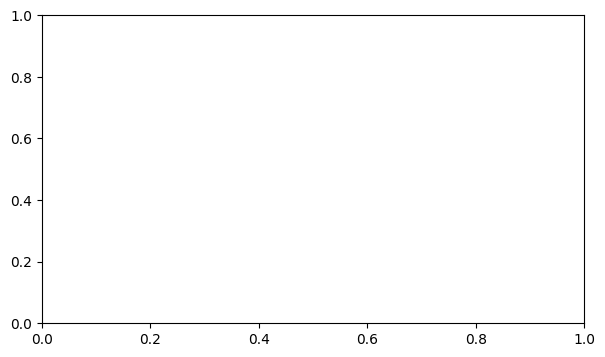

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def depth_contribution(optical_depth):
    return np.average(optical_depth, axis=1)

mean_tau = depth_contribution(tau)

plt.figure(figsize=(7, 4))
plt.imshow(mean_tau, aspect='auto', origin='lower')
plt.colorbar(label='Mean optical depth')
plt.title('Compressed view of the optical-depth field')
plt.xlabel('Wavelength index')
plt.ylabel('Atmospheric layer index')

In [4]:
mid_wavelength = wlgrid[len(wlgrid) // 2]
mid_profile = tau[:, :, len(wlgrid) // 2].mean(axis=0)

plt.figure(figsize=(5, 4))
plt.plot(mid_profile, range(len(mid_profile)))
plt.xlabel('Mean optical depth')
plt.ylabel('Layer index')
plt.title(f'Optical depth near {mid_wavelength:.2f} um')
plt.grid(alpha=0.2)

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [ ]:
_, contribs = tm.model_full_contrib()
absorption = contribs['Absorption']
label, abs_rprs, abs_tau, _ = absorption[0]

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, rprs[::-1], label='Total spectrum', lw=2)
plt.plot(wlgrid, abs_rprs[::-1], label=label, lw=2)
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('Comparing one contribution to the total signal')
plt.legend()
plt.grid(alpha=0.2)

print(f'Isolated contribution tau shape: {abs_tau.shape}')

A final useful habit is to compare one isolated contribution to the total spectrum. That comparison tells you whether a process is shaping the overall continuum, sharpening individual features, or doing almost nothing in the current setup.

Comparing a single contribution to the full spectrum is often more instructive than reading a list of enabled physics. It tells you which structures are robust and which only appear once several processes interact. That is especially useful when you start modifying the atmosphere or preparing a retrieval setup.